In [167]:
import pandas as pd
import re
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import matplotlib.colors as c
import numpy as np
from pathlib import Path
import random

from dataclasses import dataclass

def parse_gem5_stats_to_dataframe(filepath):
  data = []
  
  stat_pattern = re.compile(r'^\s*([a-zA-Z0-9_\.:-]+)\s+([^#]+?)\s*#\s*(.*)$')
  
  with open(filepath, 'r', encoding='utf-8') as file:
    for line in file:
      line = re.sub(r'\\', '', line).strip()
      
      if not line or line.startswith('---'):
        continue
      
      match = stat_pattern.match(line)
      if match:
        metric = match.group(1).strip()
        raw_values : str = match.group(2).strip()
        description = match.group(3).strip()
        
        tokens = raw_values.split()
        primary_value_str = tokens[0] if tokens else ""
        
        try:
          primary_value = float(primary_value_str)
        except (ValueError, TypeError):
          primary_value = primary_value_str
        
        data.append({
          'Metric': metric,
          'Value': primary_value,
          'Description': description,
          'Raw_Values': raw_values
        })
  if len(data) == 0:
    print(filepath)
  return pd.DataFrame(data)

In [168]:
@dataclass
class AlgorithmResult:
    name: str
    dir: Path
    df: pd.DataFrame

@dataclass
class CPUResults:
    name: str
    dir: Path
    results: list[AlgorithmResult]

@dataclass
class Run:
    dir: Path
    cpus: list[CPUResults]

@dataclass
class Metric():
  id: str
  name: str

@dataclass
class Plot():
  name: str
  metrics: list[Metric]
  percentage: bool
  columns_for_total_percentage_sum: list[str]


def maybe_float(s, otherwise: float = 0.0):
  try:
    return float(s)
  except (ValueError, TypeError):
    return otherwise

def get_metric_value(df: pd.DataFrame, id: str):
  row = df[df['Metric'] == id]
  if row.empty: return 0.0

  try:
      return float(row['Value'].values[0])
  except (ValueError, TypeError):
      return 0.0
  
def should_i_be_log(data): # não funciono com negatividade
  return (
      (max_val := np.max(data)) > 0 and
      (min_val := np.min([v for sublist in data for v in sublist if v > 0], initial = 0)) > 0 and
      (max_val / min_val) > 100
  )

def brightness(color):
    # Convert any Matplotlib color format (name, hex, etc.) to 0-1 RGB
    r, g, b = color[:3]
    
    # Standard formula for relative luminance (W3C / ITU-R BT.709)
    # Returns a value between 0.0 (darkest) and 1.0 (brightest)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def plot_algorithm_comparison(metrics_to_plot: list[list[Metric]], algorithms: list[AlgorithmResult], name=""):
    num_plots = len(metrics_to_plot)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(16, 5 * num_plots), sharey=False, squeeze=False)
    axes = axes.flatten()
    fig.suptitle(name)
    for i, metrics_group in enumerate(metrics_to_plot):
        ax: Axes = axes[i]
        
        x = np.arange(len(metrics_group))
        num_algos = len(algorithms)
        width = 0.8 / num_algos
        
        offsets = [(i - num_algos/2 + 0.5) * width for i in range(num_algos)]
        sort_them=True
        if sort_them:
            
            plot_data = sorted([
                (algo, [maybe_float(get_metric_value(algo.df, metric.id)) for metric in metrics_group])
                for algo in algorithms
            ], key=lambda x: x[1])

            for j, (algo, data) in enumerate(plot_data):
                b = ax.bar(x + offsets[j], data, width, label=algo.name)
                # ax.bar_label(b, labels=[f'{v:,.6f}'.rstrip("0").rstrip(".") for v in plot_data[j]], label_type='center', color='white', fontweight='bold')
                ax.bar_label(b, labels=[algo.name for _ in data], fontweight='bold')
        else:
            
            plot_data = [
                [maybe_float(get_metric_value(algo.df, metric.id)) for metric in metrics_group]
                for algo in algorithms
            ]
            for j, algo in enumerate(algorithms):
                b = ax.bar(x + offsets[j], plot_data[j], width, label=algo.name)
                # ax.bar_label(b, labels=[f'{v:,.6f}'.rstrip("0").rstrip(".") for v in plot_data[j]], label_type='center', color='white', fontweight='bold')
                ax.bar_label(b, labels=[algo.name for _ in plot_data[j]], label_type='center', color=('white'), fontweight='bold')

        # ax.set_title(f"Group {i + 1}", pad=15, fontweight='bold')
        # ax.set_ylabel('Value')
        ax.set_xticks(x)
        
        short_metrics = [m.name for m in metrics_group]
        ax.set_xticklabels(short_metrics, rotation=0)
        
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # if should_i_be_log(plot_data):
        #     ax.set_yscale('log')
        #     ax.set_ylabel('Value (Log Scale)')
            
    plt.tight_layout()
    plt.show()
A = AlgorithmResult
M = Metric


In [169]:
from pathlib import Path

# Define the target directory path
target_dir = Path("src/find_cpu_config/Cache/run")

def newest_run_dir(chud=False, cha=False, radix=False):
    def meets_requirements(d: Path):
        return (
            (not chud or d.joinpath("chud.m5out").exists()) and
            (not cha or d.joinpath("cha.m5out").exists()) and
            (not radix or d.joinpath("radix.m5out").exists())
        )
    return max(
        (d for d in target_dir.iterdir() if d.is_dir() if meets_requirements(d)), 
        key=lambda d: d.stat().st_mtime
    )

def newest_m5out(who: str) -> Path:
    subdir = f"{who}.m5out"
    candidates = [p for d in target_dir.iterdir() if d.is_dir() if (p := d.joinpath(subdir)).exists()]
    if len(candidates) < 1:
        raise ValueError(f'{who} was requested but no "{subdir}" as found')
    return max(candidates, key=lambda d: d.stat().st_mtime)

def subdirs(dir: Path):
    return (d for d in dir.iterdir() if d.is_dir())

def get_run(run_dir: Path) -> Run:
    return Run(run_dir, [
        CPUResults(cpu_dir.name, cpu_dir, [
            AlgorithmResult(algo.name, algo, parse_gem5_stats_to_dataframe(algo.joinpath("stats.txt").as_posix())
            ) for algo in subdirs(cpu_dir) if "orgb_configs" not in algo.name
        ]) for cpu_dir in subdirs(run_dir) if "build" != cpu_dir.name
    ])

def get_last_run() -> Run:
    run_dir = max(subdirs(target_dir), key=lambda d: d.stat().st_mtime)
    return get_run(run_dir)
    

run = get_run(target_dir)

In [170]:

def plot_algorithm_comparison(target_dir: Path, baseline_position: int, baseline_value: int):
    metrics_to_plot = [
        [M('sim_seconds', 'sim_seconds')],
        [M('system.cpu.ipc_total', 'ipc')],
        # [M('system.cpu.dcache.overall_miss_rate::total', 'dcache miss_rate')],
        # [M('system.cpu.icache.overall_miss_rate::total', 'icache miss_rate')],
        # [M('system.l2cache.overall_miss_rate::total', 'l2 miss_rate')],

        # [M('system.cpu.commit.fp_insts', 'float inst')],
        # [M('system.cpu.commit.int_insts', 'int inst')],
        # [M('sim_insts', "instructions")],
    ]

    run = get_run(target_dir)
    print(*[res.name for cpu_result in run.cpus for res in cpu_result.results if 'Metric' not in res.df])

    # for cpu_result in sorted_cpus:
    #     plot_algorithm_comparison(metrics_to_plot, cpu_result.results, name=cpu_result.name)

    from natsort import natsorted
    # i dont work for more than 1 metric per group
    metrics = [metrics_group[0] for metrics_group in metrics_to_plot]

    usesSiPrefixes = ['Cache']

    def simplify_si(name: str):
        prefix = next((pre for pre in usesSiPrefixes if name.startswith(pre)), None)

        if prefix is None:
            return name
        
        multipliers = {'k': 1e3, 'M': 1e6,}

        unit = name[-1] # fraco, tomar cuidado
        if (mult := name[-2]) not in multipliers:
            return name

        num = int(name[:-2].replace(prefix, ""))
        return f"{name[:-2]}{num * multipliers[mult]}{unit}"

    sorted_cpus = [
        *natsorted((cpu for cpu in run.cpus), lambda cpu: simplify_si(cpu.name))
    ]
    algos = list({algo.name for cpu_result in sorted_cpus for algo in cpu_result.results})


    ## proper order: baseline always last
    baseline = next((cpu_result for cpu_result in sorted_cpus if cpu_result.name == "baseline"))
    cpu_results = [cpu_result for cpu_result in sorted_cpus if cpu_result.name != "baseline"] 
    cpus = [cpu_result.name for cpu_result in cpu_results]

    if baseline_position < 0:
        baseline_position = len(cpus) + 1 - baseline_position

    cpu_results.insert(baseline_position, baseline)
    cpus.insert(baseline_position, baseline.name)


    data = {
        metric.name: {
            algo: [
                maybe_float(get_metric_value(res.df, metric.id)) for cpu_result in cpu_results for res in cpu_result.results if res.name == algo
            ] for algo in algos
        }
        for metric in metrics
    }


    num_metrics = len(metrics)
    num_plots = num_metrics
    
    figs = [plt.figure(figsize=(16, 5)) for _ in range(num_plots)]
    axes = [fig.add_subplot() for fig in figs]
    # fig.suptitle(name)


    for i, metric in enumerate(metrics):
        ax: Axes = axes[i]
    
        x = algos
        plot_data = list(data[metric.name].values())
        for p, x_ in zip(plot_data, x):
            ax.plot(p, label=x_)

        ax.set_title(f"{metric.name}", pad=15, fontweight='bold')
        ax.set_ylim(bottom=0)
        ax.set_xticks(np.linspace(0, len(cpus) - 1, len(cpus)))
        ax.set_xticklabels(cpus)
        
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)
            
    plt.tight_layout()
    plt.show()


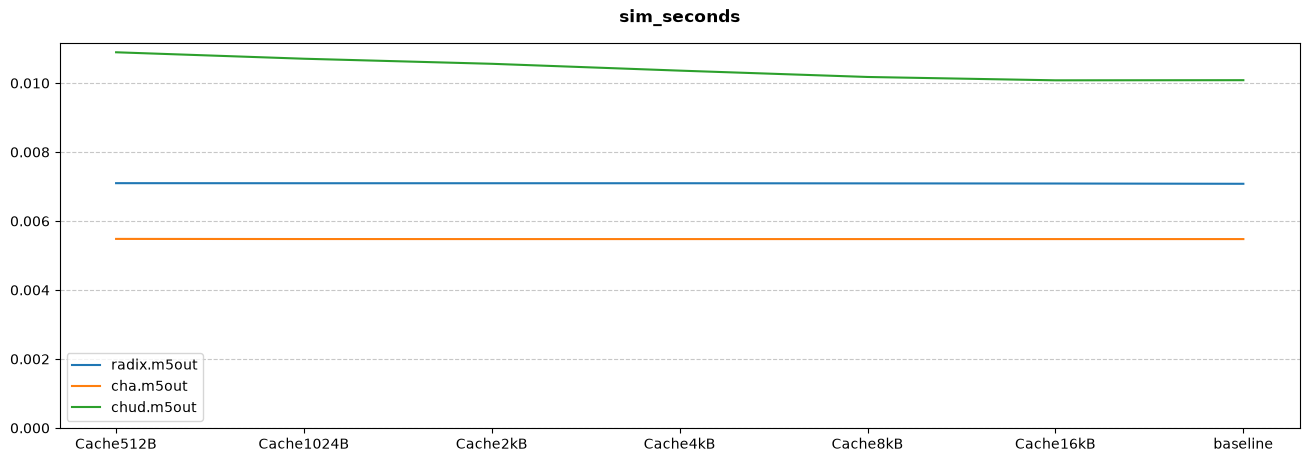

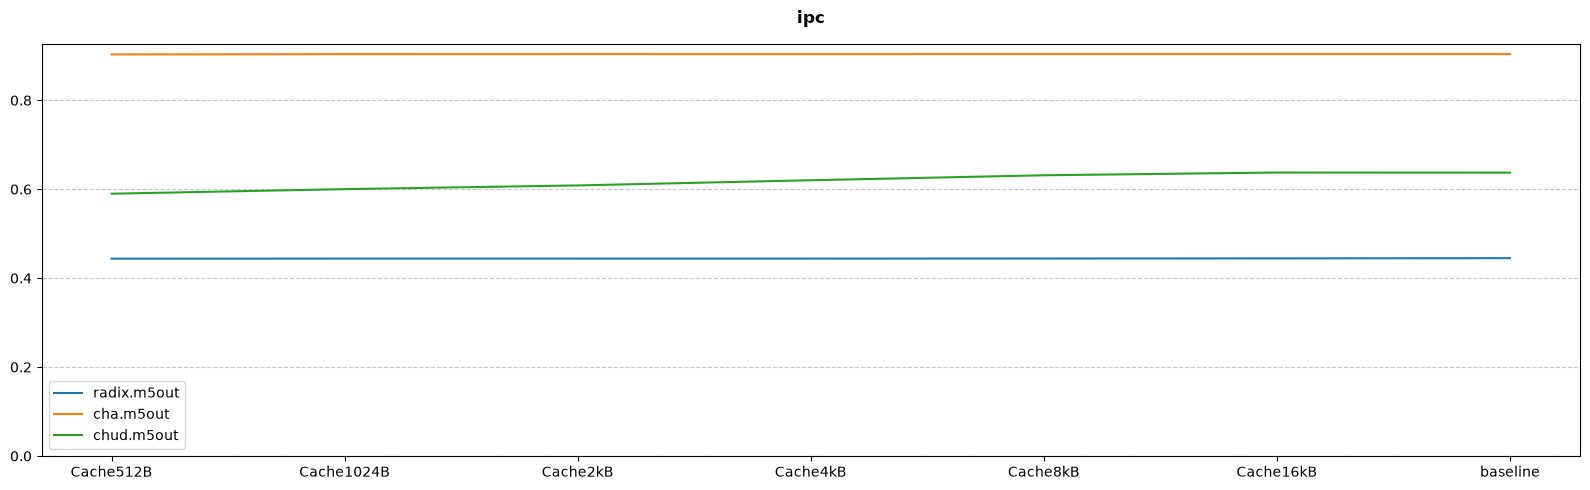

In [171]:
plot_algorithm_comparison(Path("src/find_cpu_config/Cache/run"), -1, 32)

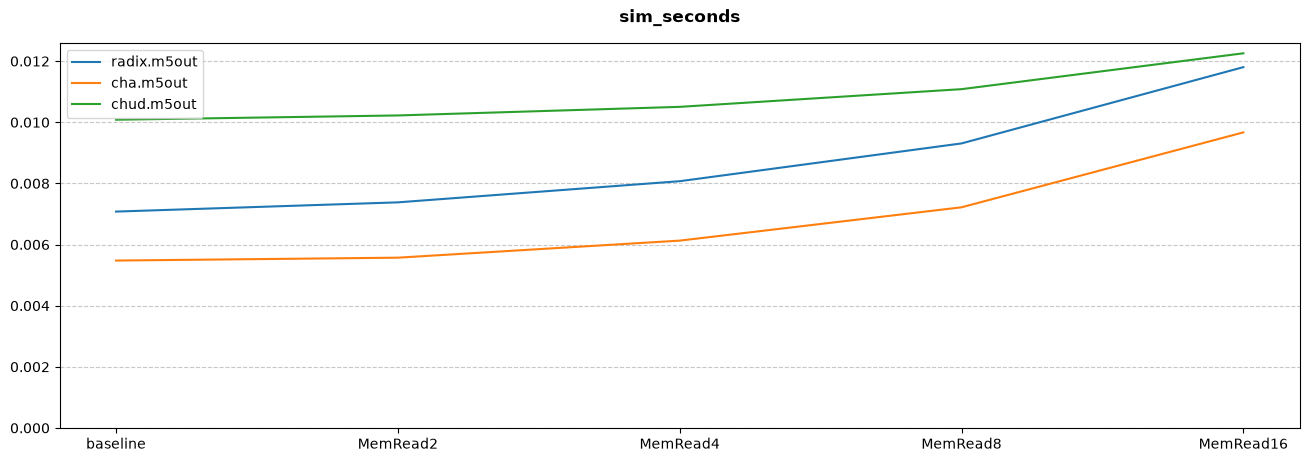

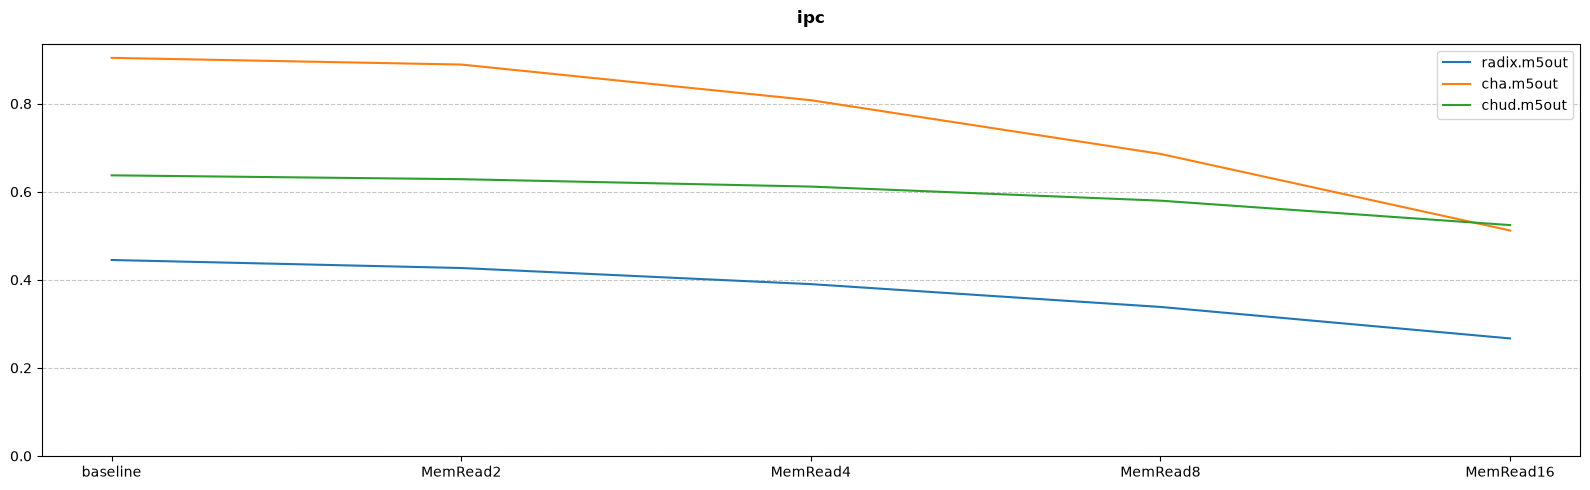

In [172]:
plot_algorithm_comparison(Path("src/find_cpu_config/MemRead/run"), 0, 1)

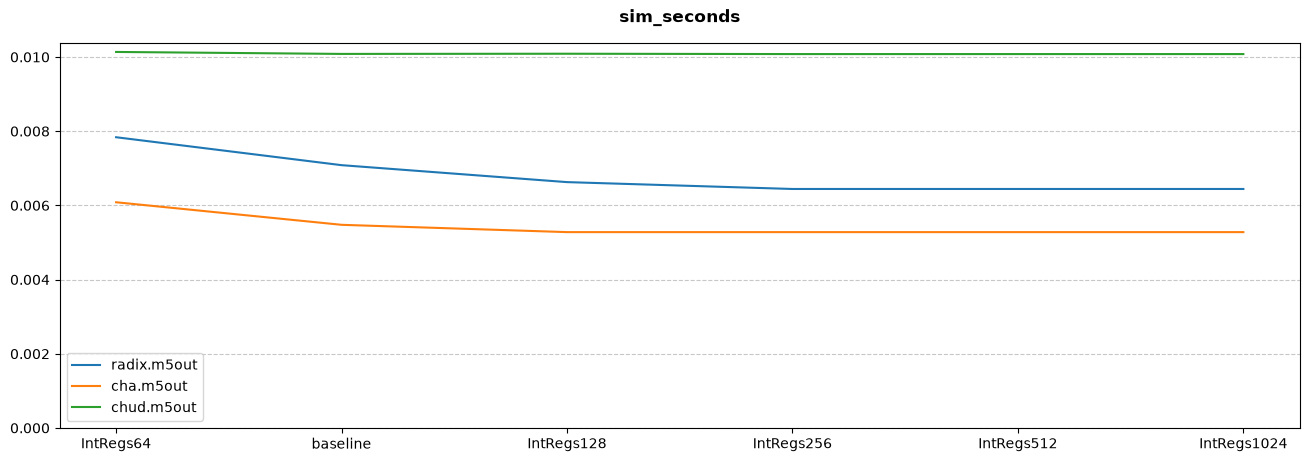

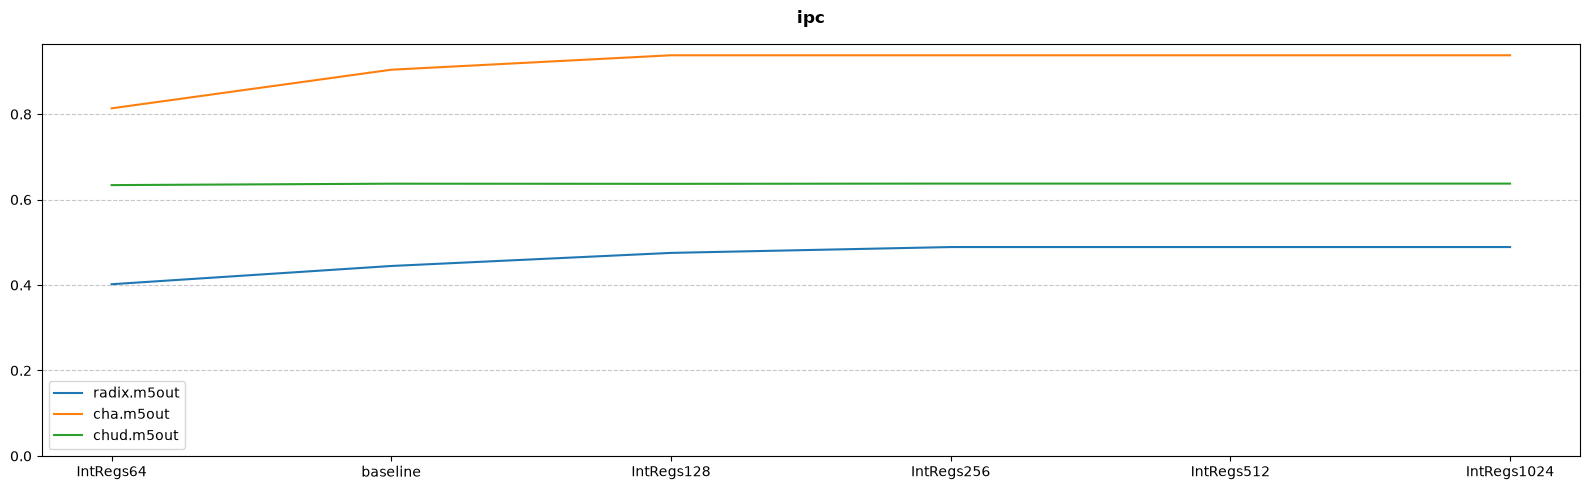

In [173]:
plot_algorithm_comparison(Path("src/find_cpu_config/IntRegs/run"), 1, 2)